# Hierarchical Attention (HA) — 20-Seed × 3-Fold Nested CV (Fixed HPs + Early Stopping)

> **20 random 22/6 splits** instead of a single 5-fold partition:
> - **Outer loop**: for `seed ∈ {0, 1, ..., 19}`, use `StratifiedShuffleSplit` to draw a fresh **22-donor train / 6-donor test** stratified split.
> - **Inner 3-fold**: identical to `ha_5fold_cv_fixed_hp.ipynb` — used *only* to decide the optimal number of training epochs via early stopping on the **mean val loss across the 3 inner models**.
> - After inner CV selects `best_epoch`, a fresh model is **refit on the full 22-donor outer-train** set for `best_epoch` epochs and evaluated once on the 6 held-out donors.
> - Aggregate metrics across the **20 seeds** (mean ± std).

**HA Model (attn1=True, attn2=True):**
- **Level 1**: Cell-level attention within each cell-type group (softmax pooling)
- **Level 2**: Cell-type-level attention across cell types within a patient

**Data**: 28 donors (14 Normal + 14 Inflamed), scGPT embeddings (512-d), binary classification (Normal vs Inflamed).

### Pipeline
```
For seed in 0..19:
    StratifiedShuffleSplit(test_size=6, random_state=seed) → (22 train, 6 test)
    inner 3-fold CV on the 22
        train 3 models in parallel, mean val_loss per epoch
        early-stop on the averaged signal → best_epoch
    refit fresh model on all 22 outer_train donors for best_epoch
    evaluate ONCE on the 10 outer-test donors
Aggregate metrics across the 20 seeds (mean ± std).
```

> ⚠️ **Note**: with 20 random splits, test donors **overlap** across seeds (some donors will be in test multiple times, others zero times). This trades the "each donor tested exactly once" guarantee of k-fold CV for 20 estimates of generalization with both split + init variance.


## Block 1 — Imports

In [9]:
import os
import random
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss,
    balanced_accuracy_score,
)
import scanpy as sc
import matplotlib.pyplot as plt
from torch_geometric.utils import softmax
from torch_geometric.nn import global_add_pool, global_mean_pool
import matplotlib.pyplot as plt
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device    : {DEVICE}")

PyTorch version : 2.8.0
CUDA available  : False
Using device    : cpu


## Block 2 — Reproducibility

In [10]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed} ✓")

set_seed(42)

Random seed set to 42 ✓


## Block 3 — Hyperparameters
Centralise all settings here — only cell you need to edit.

In [11]:
# ── Data ──────────────────────────────────────────────────────
DATA_PATH = "../data_healthy_inflamed/kong_5000_healthy_inflamed_5000hvg.h5ad"
PATIENT_ID_KEY = "donor_id"
LABEL_KEY = "Type"
CELL_TYPE_KEY = "Celltype"
EMBEDDING_KEY = "X_scGPT"
LABEL_MAP = {"Heal": 0, "Infl": 1}
LABEL_NAMES = {0: "Normal", 1: "Inflamed"}
NUM_CLASSES = 2

# ── HA Model ──────────────────────────────────────────────────
ATTN1 = True       # cell-level attention
ATTN2 = True       # cell-type-level attention
N_HID = 256        # hidden dimension
N_LAYERS_LIN = 1   # number of linear layers before attention
DROPOUT = 0.3

# ── Training ──────────────────────────────────────────────────
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 150

# ── 20-Seed × Inner 3-fold CV ─────────────────────────────────
SEEDS = list(range(20))     # 0..19 inclusive
TEST_SIZE = 6              # absolute number of donors held out per seed
N_INNER_FOLDS = 3

# ── Early stopping (applied to MEAN inner val loss) ───────────
PATIENCE = 10
MIN_DELTA = 1e-4

print(f"Model: HA (attn1={ATTN1}, attn2={ATTN2})")
print(f"Hidden: {N_HID}, Layers: {N_LAYERS_LIN}, Dropout: {DROPOUT}")
print(f"LR: {LEARNING_RATE}, WD: {WEIGHT_DECAY}, MaxEpochs: {MAX_EPOCHS}")
print(f"Outer: {len(SEEDS)} seeds × StratifiedShuffleSplit(test={TEST_SIZE})")
print(f"Inner: {N_INNER_FOLDS}-fold CV per seed")
print(f"Early stopping on mean inner val loss: patience={PATIENCE}, min_delta={MIN_DELTA}")
print(f"Using device : {DEVICE}")

Model: HA (attn1=True, attn2=True)
Hidden: 256, Layers: 1, Dropout: 0.3
LR: 0.001, WD: 0.0001, MaxEpochs: 150
Outer: 20 seeds × StratifiedShuffleSplit(test=6)
Inner: 3-fold CV per seed
Early stopping on mean inner val loss: patience=10, min_delta=0.0001
Using device : cpu


## Block 4 — Load Data

In [12]:
adata = sc.read_h5ad(DATA_PATH)
print(f"Cells: {adata.shape[0]}, Features: {adata.shape[1]}")
print(f"obsm keys: {list(adata.obsm.keys())}")
print(f"Donors: {adata.obs[PATIENT_ID_KEY].nunique()}")
print(f"Cell types: {adata.obs[CELL_TYPE_KEY].nunique()}")

Cells: 105492, Features: 5000
obsm keys: ['X_scGPT']
Donors: 28
Cell types: 68


In [13]:
adata.obs["label"] = adata.obs[LABEL_KEY].map(LABEL_MAP).astype(int)

ALL_CT = sorted(adata.obs[CELL_TYPE_KEY].unique().tolist())
N_CT = len(ALL_CT)
CT_DICT = {ct: idx for idx, ct in enumerate(ALL_CT)}

embeddings = adata.obsm[EMBEDDING_KEY]
N_FEATURES = embeddings.shape[1]

df = pd.DataFrame(embeddings, index=adata.obs.index)
df["patient"] = adata.obs[PATIENT_ID_KEY].values
df["cell_type_annotation"] = adata.obs[CELL_TYPE_KEY].values
df["label"] = adata.obs["label"].values

print(f"Embedding dim: {N_FEATURES}")
print(f"Cell types: {N_CT}")
print(f"Label distribution:")
print(adata.obs.groupby(PATIENT_ID_KEY)["label"].first().value_counts())

Embedding dim: 512
Cell types: 68
Label distribution:
label
0    14
1    14
Name: count, dtype: int64


## Block 5 — HA Model Definition

In [14]:
class HAModel(nn.Module):
    """
    Hierarchical Attention MIL model (Do et al.).

    Level 1 (attn1): Attention over cells within each cell-type group.
    Level 2 (attn2): Attention over cell-type representations within a patient.
    """
    def __init__(self, n_in, n_out=2, attn1=True, attn2=True,
                 dropout=0.0, n_layers_lin=1, n_hid=256):
        super().__init__()
        self.attn1 = attn1
        self.attn2 = attn2

        self.lin = nn.Sequential(
            *self._build_layers(n_layers_lin, n_in, n_hid, n_hid, dropout)
        )
        curr_in = n_in if len(self.lin) == 0 else n_hid
        self.n_in1 = curr_in

        self.w_c = nn.Sequential(nn.Linear(curr_in, 1), nn.Dropout(dropout))
        self.w_ct = nn.Sequential(nn.Linear(curr_in, 1), nn.Dropout(dropout))
        self.lin_out = nn.Linear(curr_in, n_out)

    def _build_layers(self, n_layers, n_in, n_hid, n_out, dropout):
        layers = []
        for i in range(n_layers):
            c_in = n_in if i == 0 else n_hid
            c_out = n_out if i == n_layers - 1 else n_hid
            layers.extend([nn.Linear(c_in, c_out), nn.ReLU(), nn.Dropout(dropout)])
        return layers

    def forward(self, X, batch, ct_size, n_ct):
        X = self.lin(X)
        if self.attn1:
            w_c = softmax(self.w_c(X).squeeze(-1), batch)
            X = global_add_pool(X * w_c.unsqueeze(dim=-1), batch, size=ct_size)
        else:
            X = global_mean_pool(X, batch, size=ct_size)

        X = X.reshape(-1, n_ct, self.n_in1)

        if self.attn2:
            w_ct = torch.softmax(self.w_ct(X), dim=1)
            X = torch.sum(X * w_ct, dim=1)
        else:
            X = torch.mean(X, dim=1)

        logits = self.lin_out(X)
        return logits

print("HAModel defined ✓")

HAModel defined ✓


## Block 6 — Utility Functions

In [15]:
def get_data(df, all_ct, samples, n_features):
    ct_dict = {ct: idx for idx, ct in enumerate(all_ct)}
    n_ct = len(all_ct)
    Xs, batches = [], []
    for idx, patient in enumerate(samples["patient"].tolist()):
        sample_df = df[df["patient"] == patient]
        x = sample_df.iloc[:, :n_features].to_numpy()
        batch = [idx * n_ct + ct_dict[ct] for ct in sample_df["cell_type_annotation"].tolist()]
        Xs.append(x)
        batches.append(batch)
    Xs = torch.tensor(np.concatenate(Xs), dtype=torch.float)
    batches = torch.tensor(np.concatenate(batches), dtype=torch.long)
    ys = torch.tensor(samples["label"].tolist(), dtype=torch.long)
    return Xs, ys, batches


def compute_class_weights(labels):
    n_total = len(labels)
    weights = []
    for c in range(NUM_CLASSES):
        n_c = (labels == c).sum()
        weights.append(n_total / (NUM_CLASSES * n_c) if n_c > 0 else 1.0)
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def compute_fold_metrics(labels_np, preds_np, probs_np):
    disease_probs = probs_np[:, 1]
    cm = confusion_matrix(labels_np, preds_np)
    TN, FP, FN, TP = cm.ravel()

    accuracy    = (TP + TN) / len(labels_np)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    f1          = (2 * precision * sensitivity / (precision + sensitivity)
                   if (precision + sensitivity) > 0 else 0.0)

    try:    auroc = roc_auc_score(labels_np, disease_probs)
    except ValueError: auroc = float("nan")
    try:    auprc = average_precision_score(labels_np, disease_probs)
    except ValueError: auprc = float("nan")

    mcc   = matthews_corrcoef(labels_np, preds_np)
    brier = brier_score_loss(labels_np, disease_probs)
    balanced_acc = balanced_accuracy_score(labels_np, preds_np)

    return dict(
        accuracy=accuracy, sensitivity=sensitivity, specificity=specificity,
        precision=precision, f1=f1, auroc=auroc, auprc=auprc,
        mcc=mcc, brier=brier, balanced_accuracy=balanced_acc,
        TP=TP, TN=TN, FP=FP, FN=FN,
    )

print("Utility functions defined ✓")

Utility functions defined ✓


## Block 7 — Train and Evaluate Functions

In [16]:
def train_one_epoch(model, X, y, batch_idx, ct_size, n_ct, criterion, optimizer):
    model.train()
    optimizer.zero_grad()
    logits = model(X, batch_idx, ct_size, n_ct)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    preds = logits.argmax(dim=1)
    acc = (preds == y).float().mean().item() * 100.0
    return loss.item(), acc


@torch.no_grad()
def evaluate(model, X, y, batch_idx, ct_size, n_ct, criterion):
    model.eval()
    logits = model(X, batch_idx, ct_size, n_ct)
    loss = criterion(logits, y)
    probs = torch.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)
    acc = (preds == y).float().mean().item() * 100.0
    return loss.item(), acc, preds.cpu().numpy(), y.cpu().numpy(), probs.cpu().numpy()

print("Train/evaluate functions defined ✓")

Train/evaluate functions defined ✓


## Block 8 — Prepare Patient-Level Samples

In [17]:
samples = df[["patient", "label"]].drop_duplicates().reset_index(drop=True)
all_labels = samples["label"].values

print(f"Total donors  : {len(samples)}")
print(f"  Normal   (0)  : {(all_labels == 0).sum()}")
print(f"  Inflamed (1)  : {(all_labels == 1).sum()}")

Total donors  : 28
  Normal   (0)  : 14
  Inflamed (1)  : 14


## Block 9 — Preview the 20-Seed Splits (Dry Run)

In [18]:
print("20-Seed StratifiedShuffleSplit preview (test_size=6)")
print("=" * 70)

for seed in SEEDS[:5]:  # show first 5 to keep output short
    sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
    train_idx, test_idx = next(sss.split(np.arange(len(samples)), all_labels))

    train_labels = all_labels[train_idx]
    test_labels  = all_labels[test_idx]
    assert len(set(train_idx) & set(test_idx)) == 0

    print(f"Seed {seed:>2}:")
    print(f"  Train : {len(train_idx):>3} donors  "
          f"Normal={(train_labels==0).sum():>2}  Inflamed={(train_labels==1).sum():>2}")
    print(f"  Test  : {len(test_idx):>3} donors  "
          f"Normal={(test_labels==0).sum():>2}  Inflamed={(test_labels==1).sum():>2}")

print(f"\n(... {len(SEEDS)-5} more seeds will run identically ...)")
print("All splits verified — no donor leakage within a seed ✓")

# Quick check: how often does each donor land in test across all 20 seeds?
test_counts = np.zeros(len(samples), dtype=int)
for seed in SEEDS:
    sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
    _, test_idx = next(sss.split(np.arange(len(samples)), all_labels))
    test_counts[test_idx] += 1

print(f"\nTest-set coverage across {len(SEEDS)} seeds:")
print(f"  Min times in test : {test_counts.min()}")
print(f"  Max times in test : {test_counts.max()}")
print(f"  Mean              : {test_counts.mean():.2f}  "
      f"(expected ≈ {len(SEEDS)*TEST_SIZE/len(samples):.2f})")
print(f"  Donors never in test : {(test_counts == 0).sum()}")

# Show the actual test donors selected for seed 0
sss0 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=0)
_, test_idx0 = next(sss0.split(np.arange(len(samples)), all_labels))
test_donors_seed0 = samples.iloc[test_idx0].reset_index(drop=True)

print(f"\nTest donors for seed 0 ({len(test_donors_seed0)} donors):")
print("-" * 70)
for _, row in test_donors_seed0.iterrows():
    print(f"  {row['patient']:<40}  label={LABEL_NAMES[int(row['label'])]}")

20-Seed StratifiedShuffleSplit preview (test_size=6)
Seed  0:
  Train :  22 donors  Normal=11  Inflamed=11
  Test  :   6 donors  Normal= 3  Inflamed= 3
Seed  1:
  Train :  22 donors  Normal=11  Inflamed=11
  Test  :   6 donors  Normal= 3  Inflamed= 3
Seed  2:
  Train :  22 donors  Normal=11  Inflamed=11
  Test  :   6 donors  Normal= 3  Inflamed= 3
Seed  3:
  Train :  22 donors  Normal=11  Inflamed=11
  Test  :   6 donors  Normal= 3  Inflamed= 3
Seed  4:
  Train :  22 donors  Normal=11  Inflamed=11
  Test  :   6 donors  Normal= 3  Inflamed= 3

(... 15 more seeds will run identically ...)
All splits verified — no donor leakage within a seed ✓

Test-set coverage across 20 seeds:
  Min times in test : 1
  Max times in test : 7
  Mean              : 4.29  (expected ≈ 4.29)
  Donors never in test : 0

Test donors for seed 0 (6 donors):
----------------------------------------------------------------------
  139892                                    label=Inflamed
  N11                       

## Block 9b — Export Per-Seed Donor Splits to CSV
For every seed, dump the donor IDs assigned to each split (outer_train, outer_test, and inner_train / inner_val for each of the 3 inner folds). One long-format CSV: easy to filter by seed / fold / split.

In [19]:
os.makedirs("results", exist_ok=True)
split_rows = []

for seed_id in SEEDS:
    # Outer split — must match Block 10 exactly
    sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed_id)
    outer_train_idx, outer_test_idx = next(sss.split(np.arange(len(samples)), all_labels))

    outer_train_samples = samples.iloc[outer_train_idx].reset_index(drop=True)
    outer_test_samples  = samples.iloc[outer_test_idx].reset_index(drop=True)
    outer_train_labels  = outer_train_samples["label"].values

    for _, r in outer_train_samples.iterrows():
        split_rows.append({"seed": seed_id, "fold": -1, "split": "outer_train",
                           "donor_id": r["patient"], "label": LABEL_NAMES[int(r["label"])]})
    for _, r in outer_test_samples.iterrows():
        split_rows.append({"seed": seed_id, "fold": -1, "split": "outer_test",
                           "donor_id": r["patient"], "label": LABEL_NAMES[int(r["label"])]})

    # Inner CV — must match Block 10 exactly
    inner_skf = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=seed_id)
    for inner_fold, (tr_idx, val_idx) in enumerate(
        inner_skf.split(np.arange(len(outer_train_samples)), outer_train_labels), start=1
    ):
        for _, r in outer_train_samples.iloc[tr_idx].iterrows():
            split_rows.append({"seed": seed_id, "fold": inner_fold, "split": "inner_train",
                               "donor_id": r["patient"], "label": LABEL_NAMES[int(r["label"])]})
        for _, r in outer_train_samples.iloc[val_idx].iterrows():
            split_rows.append({"seed": seed_id, "fold": inner_fold, "split": "inner_val",
                               "donor_id": r["patient"], "label": LABEL_NAMES[int(r["label"])]})

splits_df = pd.DataFrame(split_rows)
out_path  = "results/ha_20seeds_3fold_donor_splits.csv"
splits_df.to_csv(out_path, index=False)

print(f"Saved {len(splits_df)} rows → {out_path}")
print("\nRow counts per split (across all seeds):")
print(splits_df.groupby('split').size().to_string())
print("\nPreview (seed 0):")
print(splits_df[splits_df['seed'] == 0]
      .groupby(['split', 'fold']).size().to_string())

Saved 1880 rows → results/ha_20seeds_3fold_donor_splits.csv

Row counts per split (across all seeds):
split
inner_train    880
inner_val      440
outer_test     120
outer_train    440

Preview (seed 0):
split        fold
inner_train   1      14
              2      15
              3      15
inner_val     1       8
              2       7
              3       7
outer_test   -1       6
outer_train  -1      22


## Block 10 — 20-Seed × Inner 3-Fold CV Training Loop

For each **seed** ∈ {0, 1, …, 19}:
1. `StratifiedShuffleSplit(test_size=6, random_state=seed)` → 22 train / 6 test donors.
2. Run a **stratified inner 3-fold CV** on the 22 train donors:
   - Train 3 fresh HA models in parallel, one per inner fold.
   - At each epoch, compute the **mean val loss across the 3 inner models**.
   - Early-stop on this averaged signal → record `best_epoch`.
3. **Refit** a fresh HA model on **all 22 outer-train donors** for exactly `best_epoch` epochs.
4. Evaluate the refit model **once** on the 10 outer-test donors and record metrics.

> Inner CV uses `random_state = seed` and model/optimizer seeding uses `set_seed(seed)` (matching `step5b_celltype_pseudobulk.ipynb`) so each seed is reproducible.


In [20]:
def build_fold_tensors(samples_subset):
    """Build (X, y, batch, ct_size) on DEVICE for a donor subset."""
    X, y, b = get_data(df, ALL_CT, samples_subset, N_FEATURES)
    X, y, b = X.to(DEVICE), y.to(DEVICE), b.to(DEVICE)
    ct_size = N_CT * len(samples_subset)
    return X, y, b, ct_size


def make_model_optim_sched(train_labels_fold, max_epochs):
    """Fresh HA model + Adam + CosineAnnealingLR + weighted CE."""
    model = HAModel(
        n_in=N_FEATURES, n_out=NUM_CLASSES,
        attn1=ATTN1, attn2=ATTN2,
        dropout=DROPOUT, n_layers_lin=N_LAYERS_LIN, n_hid=N_HID,
    ).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    criterion = nn.CrossEntropyLoss(weight=compute_class_weights(train_labels_fold))
    return model, optimizer, scheduler, criterion


seed_metrics = []
all_seed_results = []

for seed_id in SEEDS:
    print(f"\n{'═'*70}")
    print(f"  SEED {seed_id+1:>2}/{len(SEEDS)}   (random_state={seed_id})")
    print(f"{'═'*70}")

    # ── Outer split (StratifiedShuffleSplit on patient indices) ──
    sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed_id)
    outer_train_idx, outer_test_idx = next(
        sss.split(np.arange(len(samples)), all_labels)
    )
    assert len(set(outer_train_idx) & set(outer_test_idx)) == 0, "Outer leakage!"

    outer_train_samples = samples.iloc[outer_train_idx].reset_index(drop=True)
    outer_test_samples  = samples.iloc[outer_test_idx].reset_index(drop=True)
    outer_train_labels  = outer_train_samples["label"].values

    print(f"  Outer-train balance : Normal={(outer_train_labels==0).sum()}  "
          f"Inflamed={(outer_train_labels==1).sum()}")
    print(f"  Outer-test  balance : Normal={(outer_test_samples['label']==0).sum()}  "
          f"Inflamed={(outer_test_samples['label']==1).sum()}")

    # ─────────────────────────────────────────────────────────────
    #  INNER 3-FOLD CV → find best_epoch via averaged val loss
    # ─────────────────────────────────────────────────────────────
    inner_skf = StratifiedKFold(
        n_splits=N_INNER_FOLDS, shuffle=True,
        random_state=seed_id
    )

    inner_models = []
    inner_data   = []
    set_seed(seed_id)
    for inner_fold, (inner_tr_idx, inner_val_idx) in enumerate(
        inner_skf.split(np.arange(len(outer_train_samples)), outer_train_labels), start=1
    ):
        assert len(set(inner_tr_idx) & set(inner_val_idx)) == 0, "Inner leakage!"
        inner_tr  = outer_train_samples.iloc[inner_tr_idx].reset_index(drop=True)
        inner_val = outer_train_samples.iloc[inner_val_idx].reset_index(drop=True)

        X_tr, y_tr, b_tr, ctsz_tr = build_fold_tensors(inner_tr)
        X_val, y_val, b_val, ctsz_val = build_fold_tensors(inner_val)

        model, opt, sched, crit = make_model_optim_sched(
            inner_tr["label"].values, max_epochs=MAX_EPOCHS
        )
        inner_models.append((model, opt, sched, crit))
        inner_data.append((X_tr, y_tr, b_tr, ctsz_tr, X_val, y_val, b_val, ctsz_val))
        print(f"  Inner fold {inner_fold}: train={len(inner_tr):>2}  val={len(inner_val):>2}  "
              f"(val Normal={(inner_val['label']==0).sum()}  Inflamed={(inner_val['label']==1).sum()})")

    best_mean_val_loss = float("inf")
    best_epoch = 1
    patience_counter = 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        val_losses, val_accs = [], []
        for (model, opt, sched, crit), \
            (X_tr, y_tr, b_tr, ctsz_tr, X_val, y_val, b_val, ctsz_val) in zip(
                inner_models, inner_data
        ):
            train_one_epoch(model, X_tr, y_tr, b_tr, ctsz_tr, N_CT, crit, opt)
            vl, va, _, _, _ = evaluate(model, X_val, y_val, b_val, ctsz_val, N_CT, crit)
            sched.step()
            val_losses.append(vl)
            val_accs.append(va)

        mean_val_loss = float(np.mean(val_losses))
        mean_val_acc  = float(np.mean(val_accs))
        history.append((epoch, mean_val_loss, mean_val_acc))

        if mean_val_loss < best_mean_val_loss - MIN_DELTA:
            best_mean_val_loss = mean_val_loss
            best_epoch = epoch
            patience_counter = 0
            marker = " ✓"
        else:
            patience_counter += 1
            marker = ""

        if epoch == 1 or epoch % 5 == 0 or marker:
            print(f"    Ep [{epoch:03d}/{MAX_EPOCHS}]  "
                  f"meanValLoss={mean_val_loss:.4f}  meanValAcc={mean_val_acc:.1f}%  "
                  f"patience={patience_counter}/{PATIENCE}{marker}")

        if patience_counter >= PATIENCE:
            print(f"  ⏹  Early stopping at epoch {epoch}  →  best_epoch={best_epoch}  "
                  f"(mean val_loss={best_mean_val_loss:.4f})")
            break
    else:
        print(f"  Reached MAX_EPOCHS={MAX_EPOCHS}  →  best_epoch={best_epoch}  "
              f"(mean val_loss={best_mean_val_loss:.4f})")

    # ─────────────────────────────────────────────────────────────
    #  REFIT on full outer-train for best_epoch
    # ─────────────────────────────────────────────────────────────
    print(f"\n  Refitting on all {len(outer_train_samples)} outer-train donors for {best_epoch} epochs ...")
    X_otr, y_otr, b_otr, ctsz_otr = build_fold_tensors(outer_train_samples)
    X_ote, y_ote, b_ote, ctsz_ote = build_fold_tensors(outer_test_samples)

    set_seed(seed_id)
    final_model, final_opt, final_sched, final_crit = make_model_optim_sched(
        outer_train_labels, max_epochs=best_epoch
    )
    for ep in range(1, best_epoch + 1):
        train_one_epoch(final_model, X_otr, y_otr, b_otr, ctsz_otr, N_CT, final_crit, final_opt)
        final_sched.step()

    # ─────────────────────────────────────────────────────────────
    #  EVALUATE ONCE on outer-test
    # ─────────────────────────────────────────────────────────────
    test_loss, test_acc, test_preds, test_labels, test_probs = evaluate(
        final_model, X_ote, y_ote, b_ote, ctsz_ote, N_CT, final_crit
    )

    os.makedirs("checkpoints_20seeds", exist_ok=True)
    torch.save(
        final_model.state_dict(),
        f"checkpoints_20seeds/best_ha_model_seed{seed_id:02d}.pt"
    )

    metrics = compute_fold_metrics(test_labels, test_preds, test_probs)
    metrics["seed"] = seed_id
    metrics["best_epoch"] = best_epoch
    metrics["inner_best_mean_val_loss"] = best_mean_val_loss
    metrics["outer_test_loss"] = test_loss
    seed_metrics.append(metrics)

    def outcome(t, p):
        if t == 0 and p == 0: return "TN — Correct Normal"
        if t == 1 and p == 1: return "TP — Correct Inflamed"
        if t == 0 and p == 1: return "FP — Normal→Inflamed"
        return                       "FN — Inflamed→Normal"

    seed_rows = [
        {
            "seed": seed_id,
            "donor_id": outer_test_samples.iloc[i]["patient"],
            "true": LABEL_NAMES[int(test_labels[i])],
            "pred": LABEL_NAMES[int(test_preds[i])],
            "prob_normal": round(float(test_probs[i, 0]), 3),
            "prob_inflamed":  round(float(test_probs[i, 1]), 3),
            "correct": bool(test_preds[i] == test_labels[i]),
            "outcome": outcome(int(test_labels[i]), int(test_preds[i])),
        }
        for i in range(len(test_preds))
    ]
    all_seed_results.extend(seed_rows)

    print(f"  Seed {seed_id:>2} → "
          f"AUROC={metrics['auroc']:.3f}  MCC={metrics['mcc']:.3f}  "
          f"F1={metrics['f1']:.3f}  Acc={metrics['accuracy']*100:.1f}%  "
          f"Sen={metrics['sensitivity']*100:.1f}%  Spe={metrics['specificity']*100:.1f}%  "
          f"(best_epoch={best_epoch})")


══════════════════════════════════════════════════════════════════════
  SEED  1/20   (random_state=0)
══════════════════════════════════════════════════════════════════════
  Outer-train balance : Normal=11  Inflamed=11
  Outer-test  balance : Normal=3  Inflamed=3
Random seed set to 0 ✓


    Ep [021/150]  meanValLoss=0.6157  meanValAcc=73.8%  patience=0/10 ✓


  Inner fold 2: train=15  val= 7  (val Normal=3  Inflamed=4)
  Inner fold 3: train=15  val= 7  (val Normal=4  Inflamed=3)


    Ep [001/150]  meanValLoss=0.6904  meanValAcc=50.0%  patience=0/10 ✓


    Ep [002/150]  meanValLoss=0.6897  meanValAcc=86.3%  patience=0/10 ✓


...

    Ep [050/150]  meanValLoss=0.4926  meanValAcc=81.5%  patience=1/10


    Ep [055/150]  meanValLoss=0.5124  meanValAcc=77.4%  patience=6/10


  ⏹  Early stopping at epoch 59  →  best_epoch=49  (mean val_loss=0.4924)

  Refitting on all 22 outer-train donors for 49 epochs ...


Random seed set to 19 ✓


  Seed 19 → AUROC=0.778  MCC=0.333  F1=0.667  Acc=66.7%  Sen=66.7%  Spe=66.7%  (best_epoch=49)


## Block 11 — Aggregate Results

In [21]:
metrics_df = pd.DataFrame(seed_metrics)

print("\n" + "=" * 70)
print(f"20-SEED × INNER 3-FOLD CV RESULTS — HA Model (Fixed HP + Early Stopping)")
print("=" * 70)

display_cols = ["seed", "auroc", "auprc", "accuracy", "balanced_accuracy", "f1", "mcc",
                "sensitivity", "specificity", "brier", "best_epoch", "inner_best_mean_val_loss"]
print(metrics_df[display_cols].to_string(index=False, float_format="{:.3f}".format))

print("\n" + "-" * 70)
print(f"SUMMARY (mean ± std across {len(seed_metrics)} seeds):")
print("-" * 70)
for col in ["auroc", "auprc", "accuracy", "balanced_accuracy", "f1", "mcc",
            "sensitivity", "specificity", "brier"]:
    mean = metrics_df[col].mean()
    std = metrics_df[col].std()
    print(f"  {col:<20} : {mean:.4f} ± {std:.4f}")

os.makedirs("results", exist_ok=True)
metrics_df.to_csv("results/ha_20seeds_3fold_seed_metrics.csv", index=False)
pd.DataFrame(all_seed_results).to_csv("results/ha_20seeds_3fold_per_donor.csv", index=False)
print("\nSaved → results/ha_20seeds_3fold_seed_metrics.csv")
print("Saved → results/ha_20seeds_3fold_per_donor.csv")


20-SEED × INNER 3-FOLD CV RESULTS — HA Model (Fixed HP + Early Stopping)
 seed  auroc  auprc  accuracy  balanced_accuracy    f1   mcc  sensitivity  specificity  brier  best_epoch  inner_best_mean_val_loss
    0  0.778  0.806     0.833              0.833 0.857 0.707        1.000        0.667  0.212          40                     0.529
    1  1.000  1.000     0.833              0.833 0.800 0.707        0.667        1.000  0.130          86                     0.366
    2  1.000  1.000     1.000              1.000 1.000 1.000        1.000        1.000  0.114          77                     0.349
    3  1.000  1.000     1.000              1.000 1.000 1.000        1.000        1.000  0.142          64                     0.516
    4  1.000  1.000     0.833              0.833 0.800 0.707        0.667        1.000  0.105         146                     0.275
    5  1.000  1.000     1.000              1.000 1.000 1.000        1.000        1.000  0.094          76                     0.481
  

## Block 12 — Plot Per-Seed Metrics

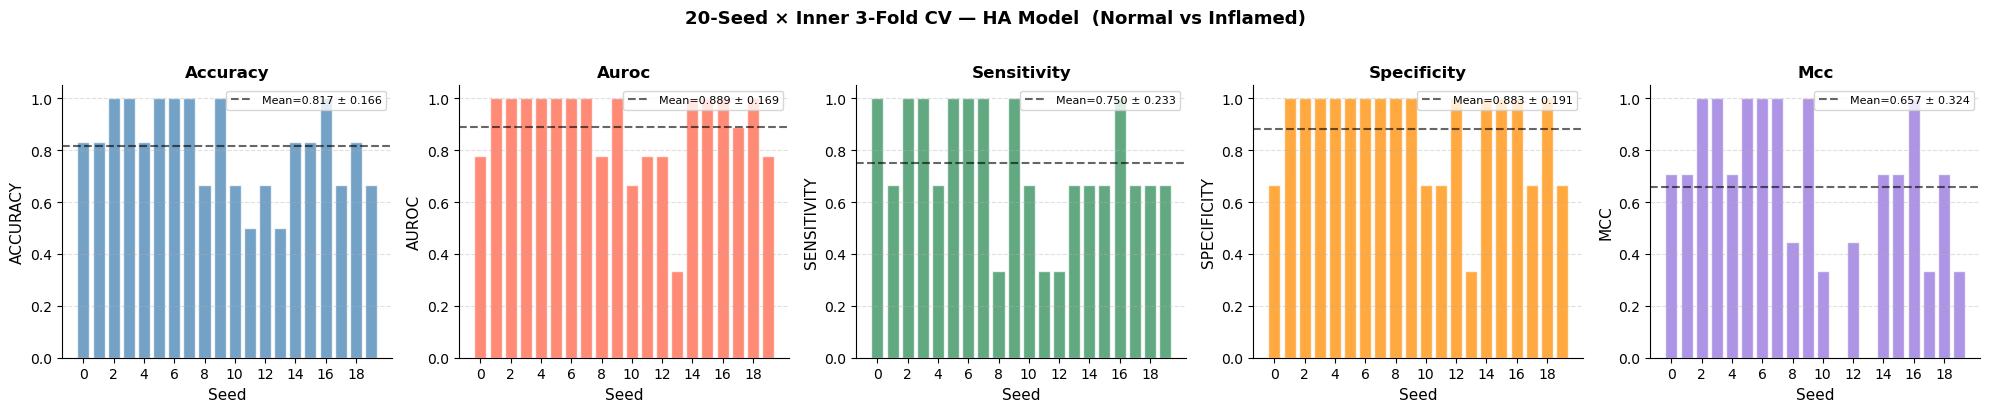

Saved → results/ha_20seeds_3fold_metrics.png ✓


In [22]:
seeds_           = [m["seed"] for m in seed_metrics]
metrics_to_plot  = ["accuracy", "auroc", "sensitivity", "specificity", "mcc"]
colors_          = ["steelblue", "tomato", "seagreen", "darkorange", "mediumpurple"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 4))

for ax, key, color in zip(axes, metrics_to_plot, colors_):
    values = [m[key] for m in seed_metrics]
    mean_v = float(np.mean(values))
    std_v  = float(np.std(values))

    ax.bar(seeds_, values, color=color, alpha=0.75,
           edgecolor="white", linewidth=1.0)
    ax.axhline(mean_v, color="black", linestyle="--", alpha=0.6,
               label=f"Mean={mean_v:.3f} ± {std_v:.3f}")
    ax.set_xlabel("Seed", fontsize=11)
    ax.set_ylabel(key.upper(), fontsize=11)
    ax.set_title(key.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_xticks(seeds_[::2])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(
    f"20-Seed × Inner 3-Fold CV — HA Model  (Normal vs Inflamed)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("results/ha_20seeds_3fold_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/ha_20seeds_3fold_metrics.png ✓")

## Block 12b — Metric Distribution Across Seeds (box + jitter)
Matches the visualization style used in `step5b_celltype_pseudobulk.ipynb`: one boxplot per metric with individual seed points overlaid as jittered scatter.

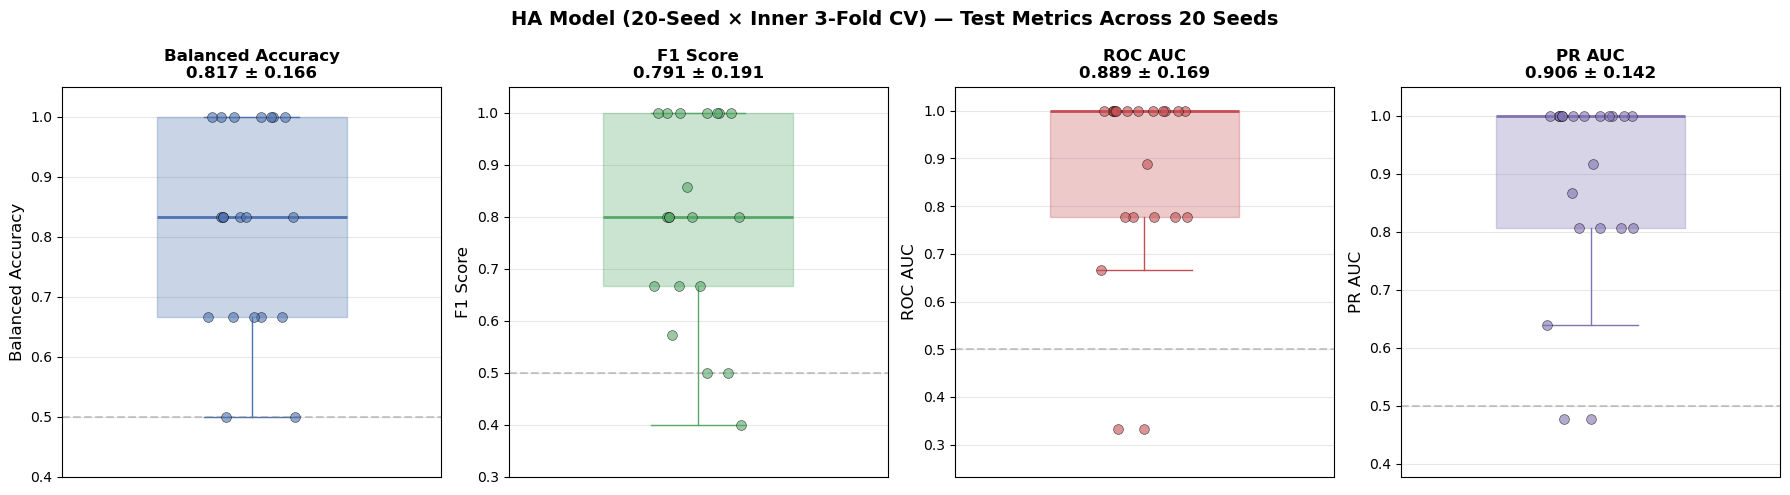

Saved → results/ha_20seeds_3fold_metric_distribution.png ✓


In [23]:
# ══════════════════════════════════════════════════════════════
# Metric Distribution Across Seeds
# ══════════════════════════════════════════════════════════════
# Load metrics from CSV so this cell is runnable on its own
# (re-uses Block 11 output: results/ha_20seeds_3fold_seed_metrics.csv)
metrics_csv_path = "results/ha_20seeds_3fold_seed_metrics.csv"
if "metrics_df" not in globals():
    metrics_df = pd.read_csv(metrics_csv_path)
    print(f"Loaded metrics from {metrics_csv_path}  (shape={metrics_df.shape})")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metric_cols   = ["balanced_accuracy", "f1", "auroc", "auprc"]
metric_labels = ["Balanced Accuracy", "F1 Score", "ROC AUC", "PR AUC"]
colors        = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
# Random baseline: 0.5 for threshold/ranking metrics; positive-class prevalence for PR AUC.
pos_prev = float(metrics_df["TP"].sum() + metrics_df["FN"].sum()) / float(
    metrics_df["TP"].sum() + metrics_df["FN"].sum() + metrics_df["TN"].sum() + metrics_df["FP"].sum()
) if {"TP","FN","TN","FP"}.issubset(metrics_df.columns) else 0.5
baselines = {"balanced_accuracy": 0.5, "f1": 0.5, "auroc": 0.5, "auprc": pos_prev}

for ax, col, label, color in zip(axes, metric_cols, metric_labels, colors):
    vals = metrics_df[col].values
    ax.boxplot(
        vals, patch_artist=True, widths=0.5,
        boxprops=dict(facecolor=color, alpha=0.3, edgecolor=color),
        medianprops=dict(color=color, linewidth=2),
        whiskerprops=dict(color=color), capprops=dict(color=color),
        flierprops=dict(marker="o", markerfacecolor=color, markeredgecolor="k",
                        markeredgewidth=0.5, markersize=7, alpha=0.6),
    )
    jitter = np.random.RandomState(42).uniform(-0.12, 0.12, len(vals))
    ax.scatter(np.ones(len(vals)) + jitter, vals, color=color, alpha=0.6,
               zorder=3, s=50, edgecolors="k", linewidths=0.5)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f"{label}\n{vals.mean():.3f} ± {vals.std():.3f}",
                 fontsize=12, fontweight="bold")
    ax.set_xticks([])
    ax.set_ylim(max(0, vals.min() - 0.1), min(1.05, vals.max() + 0.1))
    ax.axhline(baselines[col], color="gray", linestyle="--", alpha=0.4, label="Random")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"HA Model (20-Seed × Inner 3-Fold CV) — Test Metrics Across {len(metrics_df)} Seeds",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/ha_20seeds_3fold_metric_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/ha_20seeds_3fold_metric_distribution.png ✓")

## Block 12c — Train vs Test Metric Distribution Across Seeds
Loads the per-seed checkpoints from `checkpoints_20seeds/` and evaluates each on both the outer-train (40 donors) and outer-test (10 donors) splits using the same `StratifiedShuffleSplit(test_size=6, random_state=seed)` as Blocks 10 / 9b. Plots train vs test box + jitter for **balanced accuracy, F1, ROC AUC**.

Results are also written to `results/ha_20seeds_3fold_train_vs_test_metrics.csv`.

  seed  0: train bal_acc=0.864 | test bal_acc=0.833


  seed  1: train bal_acc=0.864 | test bal_acc=0.833


  seed  2: train bal_acc=0.818 | test bal_acc=1.000


  seed  3: train bal_acc=0.818 | test bal_acc=1.000


  seed  4: train bal_acc=0.955 | test bal_acc=0.833


...

  seed 15: train bal_acc=0.909 | test bal_acc=0.833


  seed 16: train bal_acc=1.000 | test bal_acc=1.000


  seed 17: train bal_acc=0.909 | test bal_acc=0.667


  seed 18: train bal_acc=0.818 | test bal_acc=0.833


  seed 19: train bal_acc=0.909 | test bal_acc=0.667

Saved → results/ha_20seeds_3fold_train_vs_test_metrics.csv  (shape=(20, 7))


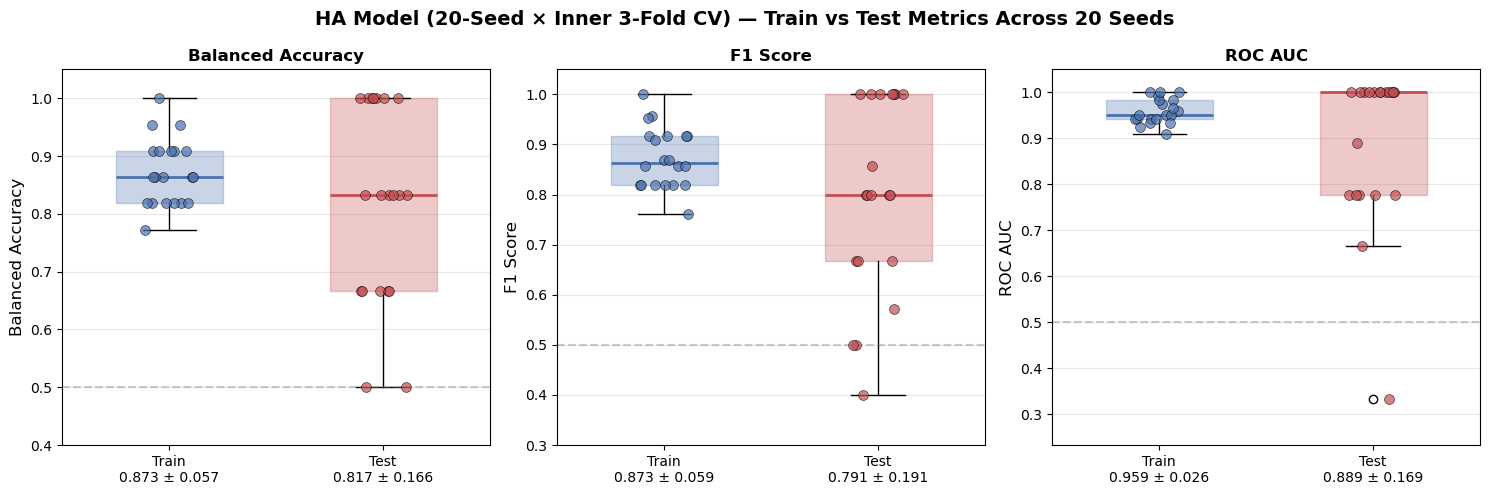

Saved → results/ha_20seeds_3fold_train_vs_test.png ✓


In [24]:
# ══════════════════════════════════════════════════════════════
# Train vs Test Metric Distribution Across Seeds
# ══════════════════════════════════════════════════════════════
CKPT_DIR = "checkpoints_20seeds"
out_csv  = "results/ha_20seeds_3fold_train_vs_test_metrics.csv"

# ---- Compute train+test metrics (re-uses saved checkpoints — no retraining) ----
if not os.path.exists(out_csv):
    # Bootstrap data if the kernel was restarted / earlier blocks weren't run
    if "df" not in globals() or "samples" not in globals() or "ALL_CT" not in globals():
        print("  ↻ Loading adata + building df (earlier data blocks not in scope) ...")
        _adata = sc.read_h5ad(DATA_PATH)
        _adata.obs["label"] = _adata.obs[LABEL_KEY].map(LABEL_MAP).astype(int)
        ALL_CT = sorted(_adata.obs[CELL_TYPE_KEY].unique().tolist())
        N_CT = len(ALL_CT)
        _emb = _adata.obsm[EMBEDDING_KEY]
        N_FEATURES = _emb.shape[1]
        df = pd.DataFrame(_emb, index=_adata.obs.index)
        df["patient"] = _adata.obs[PATIENT_ID_KEY].values
        df["cell_type_annotation"] = _adata.obs[CELL_TYPE_KEY].values
        df["label"] = _adata.obs["label"].values
        samples = df[["patient", "label"]].drop_duplicates().reset_index(drop=True)

    # Required helpers from earlier blocks — fail fast with a clear message if missing
    _missing = [n for n in ["HAModel", "get_data", "evaluate", "compute_fold_metrics"]
                if n not in globals()]
    assert not _missing, (
        f"Missing helpers {_missing}. Please run Blocks 5–7 "
        f"(HAModel definition, utility functions, train/evaluate) first."
    )

    # Inline build_fold_tensors (defined inside Block 10 originally, so not in scope when running standalone)
    def build_fold_tensors(samples_subset):
        X, y, b = get_data(df, ALL_CT, samples_subset, N_FEATURES)
        X, y, b = X.to(DEVICE), y.to(DEVICE), b.to(DEVICE)
        ct_size = N_CT * len(samples_subset)
        return X, y, b, ct_size

    all_labels_ = samples["label"].values
    seeds_to_eval = list(range(20))

    rows = []
    for seed_id in seeds_to_eval:
        ckpt = os.path.join(CKPT_DIR, f"best_ha_model_seed{seed_id:02d}.pt")
        if not os.path.exists(ckpt):
            print(f"  ⚠  Skipping seed {seed_id}: missing {ckpt}")
            continue

        # Reproduce the outer split exactly
        sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed_id)
        otr_idx, ote_idx = next(sss.split(np.arange(len(samples)), all_labels_))
        otr_samples = samples.iloc[otr_idx].reset_index(drop=True)
        ote_samples = samples.iloc[ote_idx].reset_index(drop=True)

        X_otr, y_otr, b_otr, sz_otr = build_fold_tensors(otr_samples)
        X_ote, y_ote, b_ote, sz_ote = build_fold_tensors(ote_samples)

        model = HAModel(
            n_in=N_FEATURES, n_out=NUM_CLASSES,
            attn1=ATTN1, attn2=ATTN2,
            dropout=DROPOUT, n_layers_lin=N_LAYERS_LIN, n_hid=N_HID,
        ).to(DEVICE)
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
        model.eval()
        eval_crit = nn.CrossEntropyLoss()  # unweighted — for clean reporting

        # Train metrics
        _, _, tr_preds, tr_labels, tr_probs = evaluate(
            model, X_otr, y_otr, b_otr, sz_otr, N_CT, eval_crit
        )
        tr_m = compute_fold_metrics(tr_labels, tr_preds, tr_probs)

        # Test metrics
        _, _, te_preds, te_labels, te_probs = evaluate(
            model, X_ote, y_ote, b_ote, sz_ote, N_CT, eval_crit
        )
        te_m = compute_fold_metrics(te_labels, te_preds, te_probs)

        rows.append({
            "seed": seed_id,
            "train_balanced_accuracy": tr_m["balanced_accuracy"],
            "train_f1":               tr_m["f1"],
            "train_auroc":            tr_m["auroc"],
            "test_balanced_accuracy":  te_m["balanced_accuracy"],
            "test_f1":                te_m["f1"],
            "test_auroc":             te_m["auroc"],
        })
        print(f"  seed {seed_id:>2}: train bal_acc={tr_m['balanced_accuracy']:.3f} | "
              f"test bal_acc={te_m['balanced_accuracy']:.3f}")

    tt_df = pd.DataFrame(rows)
    os.makedirs("results", exist_ok=True)
    tt_df.to_csv(out_csv, index=False)
    print(f"\nSaved → {out_csv}  (shape={tt_df.shape})")
else:
    tt_df = pd.read_csv(out_csv)
    print(f"Loaded existing metrics from {out_csv}  (shape={tt_df.shape})")

# ---- Plot: 3 panels, train vs test box + jitter ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric_pairs = [
    ("balanced_accuracy", "Balanced Accuracy"),
    ("f1",                "F1 Score"),
    ("auroc",             "ROC AUC"),
]
train_color = "#4C72B0"
test_color  = "#C44E52"
rng = np.random.RandomState(42)

for ax, (key, label) in zip(axes, metric_pairs):
    tr_vals = tt_df[f"train_{key}"].values
    te_vals = tt_df[f"test_{key}"].values

    bp = ax.boxplot(
        [tr_vals, te_vals],
        positions=[1, 2], widths=0.5, patch_artist=True,
        medianprops=dict(linewidth=2),
    )
    for patch, color in zip(bp["boxes"], [train_color, test_color]):
        patch.set_facecolor(color); patch.set_alpha(0.3); patch.set_edgecolor(color)
    for med, color in zip(bp["medians"], [train_color, test_color]):
        med.set_color(color)

    for pos, vals, color in [(1, tr_vals, train_color), (2, te_vals, test_color)]:
        jitter = rng.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), pos) + jitter, vals,
                   color=color, alpha=0.7, s=50, edgecolors="k", linewidths=0.5, zorder=3)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([
        f"Train\n{tr_vals.mean():.3f} ± {tr_vals.std():.3f}",
        f"Test\n{te_vals.mean():.3f} ± {te_vals.std():.3f}",
    ], fontsize=10)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ymin = max(0.0, min(tr_vals.min(), te_vals.min()) - 0.1)
    ymax = min(1.05, max(tr_vals.max(), te_vals.max()) + 0.1)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"HA Model (20-Seed × Inner 3-Fold CV) — Train vs Test Metrics Across {len(tt_df)} Seeds",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/ha_20seeds_3fold_train_vs_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/ha_20seeds_3fold_train_vs_test.png ✓")

## Block 13 — Training Curves per Seed

In this nested CV the per-seed "training signal" is **(a) the epoch at which inner CV
stopped (`best_epoch`)** and **(b) the mean inner val loss at that epoch**.


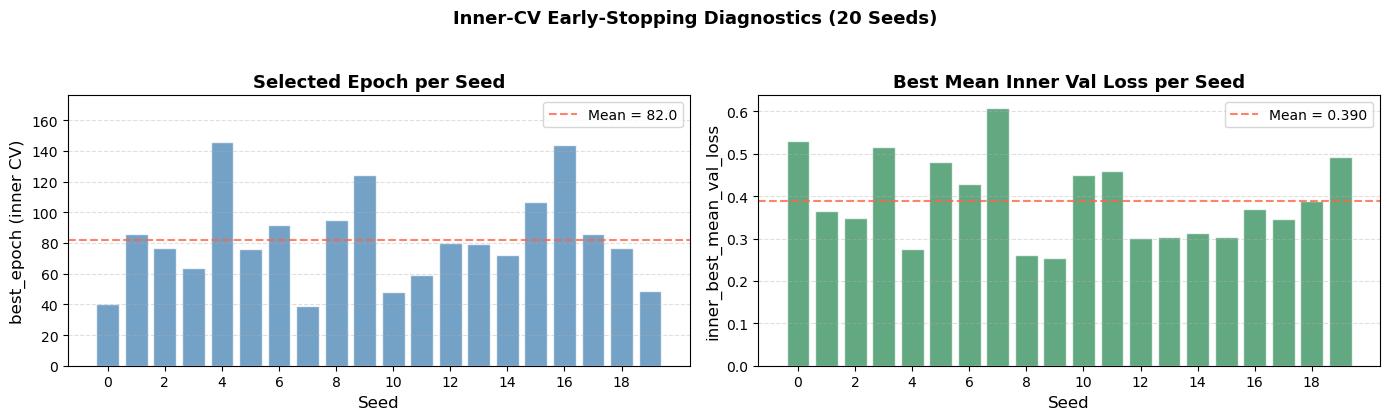

Saved → results/ha_20seeds_3fold_early_stop.png ✓


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── (a) best_epoch per seed ───────────────────────────────────
best_epochs = [m["best_epoch"] for m in seed_metrics]
mean_be     = float(np.mean(best_epochs))

axes[0].bar(seeds_, best_epochs, color="steelblue", alpha=0.75,
            edgecolor="white", linewidth=1.0)
axes[0].axhline(mean_be, color="tomato", linestyle="--", alpha=0.8,
                label=f"Mean = {mean_be:.1f}")
axes[0].set_xlabel("Seed", fontsize=12)
axes[0].set_ylabel("best_epoch (inner CV)", fontsize=12)
axes[0].set_title("Selected Epoch per Seed", fontsize=13, fontweight="bold")
axes[0].set_xticks(seeds_[::2])
axes[0].set_ylim(0, max(best_epochs) * 1.20 + 1)
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# ── (b) mean inner val loss per seed ──────────────────────────
val_losses = [m["inner_best_mean_val_loss"] for m in seed_metrics]
mean_vl    = float(np.mean(val_losses))

axes[1].bar(seeds_, val_losses, color="seagreen", alpha=0.75,
            edgecolor="white", linewidth=1.0)
axes[1].axhline(mean_vl, color="tomato", linestyle="--", alpha=0.8,
                label=f"Mean = {mean_vl:.3f}")
axes[1].set_xlabel("Seed", fontsize=12)
axes[1].set_ylabel("inner_best_mean_val_loss", fontsize=12)
axes[1].set_title("Best Mean Inner Val Loss per Seed", fontsize=13, fontweight="bold")
axes[1].set_xticks(seeds_[::2])
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Inner-CV Early-Stopping Diagnostics (20 Seeds)",
             fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig("results/ha_20seeds_3fold_early_stop.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/ha_20seeds_3fold_early_stop.png ✓")

## Block 14 — Per-Donor Reliability (Coverage Across Seeds)

In [26]:
# Aggregate per-donor predictions across the 20 seeds.
# Each donor may appear in the test set 0..N times — accuracy here is per-appearance.
per_donor_df = pd.DataFrame(all_seed_results)

donor_summary = (
    per_donor_df
    .groupby("donor_id")
    .agg(
        n_times_in_test = ("seed", "count"),
        n_correct       = ("correct", "sum"),
        mean_prob_inflamed = ("prob_inflamed", "mean"),
        true_label      = ("true", "first"),
    )
    .assign(accuracy=lambda d: d["n_correct"] / d["n_times_in_test"])
    .sort_values("n_times_in_test", ascending=False)
)
print(f"Donors appearing in ≥1 test set : {len(donor_summary)} / {len(samples)}")
print(donor_summary.to_string(float_format='{:.3f}'.format))

donor_summary.to_csv("results/ha_20seeds_3fold_donor_summary.csv")
print("\nSaved → results/ha_20seeds_3fold_donor_summary.csv")

Donors appearing in ≥1 test set : 28 / 28
          n_times_in_test  n_correct  mean_prob_inflamed true_label  accuracy
donor_id                                                                     
121881                  7          5               0.648   Inflamed     0.714
N11                     7          7               0.165     Normal     1.000
N13                     7          7               0.331     Normal     1.000
130064                  6          6               0.570   Inflamed     1.000
139892                  6          6               0.531   Inflamed     1.000
N17                     6          6               0.222     Normal     1.000
127643                  6          6               0.697   Inflamed     1.000
134300                  6          0               0.339   Inflamed     0.000
N18                     6          6               0.270     Normal     1.000
130084                  5          5               0.620   Inflamed     1.000
104689                

## Misclassified donors

Donors are aggregated across the 20 seeds. A donor is flagged as **misclassified** if its per-appearance accuracy in the test set is below 1.0 (i.e., it was predicted incorrectly at least once). For each such donor we report:

- `n_times_in_test`, `n_misclassified`, `misclassification_rate`
- `mean_prob_inflamed` (averaged across appearances)
- `error_type` — `FP` (Normal → Inflamed), `FN` (Inflamed → Normal), or `mixed` if both occur across seeds


In [27]:
import pandas as pd

# Reload from saved CSVs so this section is self-contained.
per_donor_df  = pd.read_csv('results/ha_20seeds_3fold_per_donor.csv')
donor_summary = pd.read_csv('results/ha_20seeds_3fold_donor_summary.csv').set_index('donor_id')

# ---- Misclassified-donor summary (aggregated across 20 seeds) ----
mis_per_appearance = per_donor_df.loc[~per_donor_df['correct']].copy()

def _error_type(sub):
    types = set()
    for _, r in sub.iterrows():
        if r['true'] == 'Normal' and r['pred'] == 'Inflamed':
            types.add('FP')
        elif r['true'] == 'Inflamed' and r['pred'] == 'Normal':
            types.add('FN')
    if len(types) == 1:
        return next(iter(types))
    return 'mixed' if types else 'none'

err_type = (mis_per_appearance
            .groupby('donor_id')
            .apply(_error_type)
            .rename('error_type'))

misclassified_summary = (
    donor_summary
    .loc[donor_summary['accuracy'] < 1.0]
    .assign(
        n_misclassified        = lambda d: d['n_times_in_test'] - d['n_correct'],
        misclassification_rate = lambda d: 1.0 - d['accuracy'],
    )
    .join(err_type, how='left')
    .sort_values(['misclassification_rate', 'n_times_in_test'], ascending=[False, False])
    [['true_label','n_times_in_test','n_misclassified','misclassification_rate',
      'mean_prob_inflamed','error_type']]
)

print(f"Misclassified donors (≥1 wrong prediction): "
      f"{len(misclassified_summary)} / {len(donor_summary)}")
print(misclassified_summary.to_string(float_format='{:.3f}'.format))

misclassified_summary.to_csv('results/ha_20seeds_3fold_misclassified_donors.csv')
print('\nSaved → results/ha_20seeds_3fold_misclassified_donors.csv')

Misclassified donors (≥1 wrong prediction): 7 / 28
         true_label  n_times_in_test  n_misclassified  misclassification_rate  mean_prob_inflamed error_type
donor_id                                                                                                    
134300     Inflamed                6                6                   1.000               0.339         FN
114902     Inflamed                5                5                   1.000               0.404         FN
102141       Normal                4                4                   1.000               0.638         FP
180844       Normal                2                2                   1.000               0.640         FP
191305     Inflamed                3                2                   0.667               0.601         FN
158108       Normal                2                1                   0.500               0.459         FP
121881     Inflamed                7                2                   0.286

### Misclassification-rate bar chart

Horizontal bar plot of misclassification rate per donor, colored by **true label**. Annotations show `n_misclassified / n_times_in_test`.


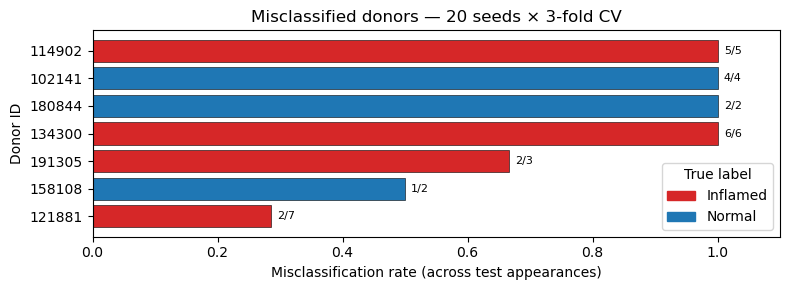

Saved → results/ha_20seeds_3fold_misclassified_donors.png


In [28]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = misclassified_summary.sort_values('misclassification_rate')
colors = plot_df['true_label'].map({'Inflamed': '#d62728', 'Normal': '#1f77b4'})

fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(plot_df))))
bars = ax.barh(plot_df.index.astype(str), plot_df['misclassification_rate'],
               color=colors, edgecolor='black', linewidth=0.4)

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{int(row['n_misclassified'])}/{int(row['n_times_in_test'])}",
            va='center', fontsize=8)

ax.set_xlabel('Misclassification rate (across test appearances)')
ax.set_ylabel('Donor ID')
ax.set_xlim(0, 1.1)
ax.set_title('Misclassified donors — 20 seeds × 3-fold CV')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#d62728', label='Inflamed'),
                   Patch(color='#1f77b4', label='Normal')],
          loc='lower right', title='True label')
plt.tight_layout()
plt.savefig('results/ha_20seeds_3fold_misclassified_donors.png', dpi=150)
plt.show()
print('Saved → results/ha_20seeds_3fold_misclassified_donors.png')

### Per-fold misclassified-donor details

Joins the per-donor predictions with `ha_20seeds_3fold_donor_splits.csv` to attach the **fold** each donor was tested in, for every seed. The table lists every misclassified `(seed, fold, donor)` with probabilities and outcome label, plus a pivot summarising counts per fold.


In [29]:
# ---- Per-fold misclassified-donor table ----
splits_df = pd.read_csv('results/ha_20seeds_3fold_donor_splits.csv')
test_splits = splits_df.loc[splits_df['split'] == 'test', ['seed','fold','donor_id']]

per_donor_with_fold = per_donor_df.merge(test_splits, on=['seed','donor_id'], how='left')

misclassified_per_fold = (
    per_donor_with_fold
    .loc[~per_donor_with_fold['correct'],
         ['seed','fold','donor_id','true','pred','prob_normal','prob_inflamed','outcome']]
    .sort_values(['fold','seed','donor_id'])
    .reset_index(drop=True)
)

print(f"Total misclassified (seed, fold, donor) rows: {len(misclassified_per_fold)}")
print(misclassified_per_fold.to_string(float_format='{:.3f}'.format))

misclassified_per_fold.to_csv(
    'results/ha_20seeds_3fold_misclassified_per_fold.csv', index=False)
print('\nSaved → results/ha_20seeds_3fold_misclassified_per_fold.csv')

# Compact pivot: how many seeds did each donor get misclassified in, per fold?
fold_pivot = (
    misclassified_per_fold
    .groupby(['donor_id','true','fold'])
    .size()
    .unstack('fold', fill_value=0)
    .add_prefix('fold_')
)
fold_pivot['total_misclassified'] = fold_pivot.sum(axis=1)
fold_pivot = fold_pivot.sort_values('total_misclassified', ascending=False)
print('\nMisclassification counts per donor × fold:')
print(fold_pivot.to_string())

fold_pivot.to_csv('results/ha_20seeds_3fold_misclassified_fold_pivot.csv')
print('\nSaved → results/ha_20seeds_3fold_misclassified_fold_pivot.csv')

Total misclassified (seed, fold, donor) rows: 22
    seed  fold donor_id      true      pred  prob_normal  prob_inflamed               outcome
0      0   NaN   102141    Normal  Inflamed        0.439          0.561  FP — Normal→Inflamed
1      1   NaN   114902  Inflamed    Normal        0.635          0.365  FN — Inflamed→Normal
2      4   NaN   134300  Inflamed    Normal        0.736          0.264  FN — Inflamed→Normal
3      8   NaN   114902  Inflamed    Normal        0.634          0.366  FN — Inflamed→Normal
4      8   NaN   134300  Inflamed    Normal        0.643          0.357  FN — Inflamed→Normal
5     10   NaN   102141    Normal  Inflamed        0.405          0.595  FP — Normal→Inflamed
6     10   NaN   121881  Inflamed    Normal        0.515          0.485  FN — Inflamed→Normal
7     11   NaN   102141    Normal  Inflamed        0.373          0.627  FP — Normal→Inflamed
8     11   NaN   121881  Inflamed    Normal        0.502          0.498  FN — Inflamed→Normal
9     11   